In [1]:
from copy import deepcopy
import itertools
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from pathlib import Path
import re
from scipy.ndimage import gaussian_filter1d
from scipy import stats


/work/dlclarge1/mallik-warmstarting/envs/nyoy_env/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import saws
import warms

In [3]:
PARAM_MAP = param_map = {
    "s1": 14562560,
    "s2": 32270848,
    "s3": 77124608,
    "s4": 134561280,
    "s5": 287183360,
    "s6": 610488320,
    "s7": 1217722368,
}


WIDTH_MAP = width_map = {
    "s0": 64,
    "s1": 128,
    "s2": 256,
    "s3": 512,
    "s4": 768,
    "s5": 1280,
    "s6": 2048,
    "s7": 3072,
}

In [4]:
for k1, v1 in param_map.items():
    if int(k1[-1]) != 3:
        continue
    for k2, v2 in param_map.items():
        if k1 == k2:
            continue
        if int(k1[-1]) >= int(k2[-1]):
            continue
        print(f"{k1}-{k2}: {256 * np.sqrt(v2 / v1)}")

s3-s4: 338.14544008258497
s3-s5: 493.99564091520614
s3-s6: 720.2481644393972
s3-s7: 1017.226398569071


---

### HELPER FUNCTIONS

In [5]:
def gaussian_smooth(data, window_size):
    # Calculate the standard deviation for the Gaussian kernel
    sigma = window_size / 2.0
    
    # Apply Gaussian filter
    smoothed_data = gaussian_filter1d(data, sigma)
    
    return smoothed_data

In [6]:
def read_tb_parquet(path: Path, retain_cols: list[str] = None) -> pd.DataFrame:
    """ Read a completed run (TODO: read incomplete runs).
    """
    df = pd.read_parquet(path)
    if 2 in df.warmstart_stage.values:
        df.flops = df.flops - df.loc[df.warmstart_stage == 2].flops.values[0]
        df.tokens = df.tokens - df.loc[df.warmstart_stage == 2].tokens.values[0]
        df = df.loc[df.warmstart_stage > 1]
    if retain_cols is not None:
        df = df[retain_cols]
    return df

In [7]:
def _parse_paths_for_meta_information(
    path: Path, 
    convert_scale_to_params: bool=True
) -> tuple[int, int, int, float]:
    """To parse the paths needed for the total learning curve set.
    """
    ## TODO: this function needs updating as and how more runs and thus paths are being processed

    k = str(path)
    # checking for token budget
    match = re.search(r'[0-9]\d*tkpm', str(k))
    D = float(match.group().split("tkpm")[0]) if match else 20.0

    # checking for parameter count
    ### check if a warmstarting path first
    is_ws = None
    _match = re.search(r's[1-9]\d*-s[1-9]\d*', str(k))
    if _match:
        base, target = _match.group().split("-")
        # NOTE: crucial flag
        is_ws = True if "/mup" not in k else False
    else:
        ### check if a scale is mentioned
        _match = re.search(r's[1-9]\d*', str(k))
        assert _match, f"No model scale information in the path: {k}"
        base = target = _match.group()

    # check for potential shrinking HP
    _match = re.search(r'shrinking=([0-9]*\.?[0-9]+)', str(k))
    if _match:
        lambda_shrink =float(_match.group().split("=")[-1])
    else:
        lambda_shrink = 0.4 if is_ws else 0

    if convert_scale_to_params:
        base = PARAM_MAP[base]
        target = PARAM_MAP[target]
    
    return D, base, target, lambda_shrink

In [8]:
def get_pareto_frontier(df, col_name="Validation Loss"): 
    """ Function to compute Pareto over FLOPs.
    """
    df_sorted = df.sort_values(by="flops")
    pareto_points = []
    min_loss_so_far = float('inf')
    for _, row in df_sorted.iterrows():
        if row[col_name] < min_loss_so_far:
            pareto_points.append(row)
            min_loss_so_far = row[col_name]

    return pd.DataFrame(pareto_points)

In [9]:
def fit_alpha_intercept_vs_flops(
    flops: np.ndarray | list | pd.Series,
    entity: np.ndarray | list | pd.Series,
) -> list[float | float | float | float | float]:
    log_C = np.log(flops)
    log_y = np.log(entity)
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_C, log_y)
    
    return slope, intercept, r_value, p_value, std_err

In [10]:
def plot_fitted_data(
    x: np.ndarray, 
    y: np.ndarray, 
    slope: float | np.ndarray, 
    intercept: float | np.ndarray,
    y_label: str,
    C_pred: np.ndarray | None
) -> None:
    plot_errors = False
    _slope = slope
    _intercept = intercept
    if not isinstance(slope, float) and not isinstance(intercept, float):
        assert len(slope)==2
        assert len(intercept)==2
        plot_errors = True
        _slope = slope[0]
        _intercept = intercept[0]

    plt.clf()
    plt.scatter(np.exp(x), np.exp(y), label="raw data")
    plt.plot(
        np.exp(x), 
        np.exp(_intercept + _slope * x), 
        color="red", 
        label="fitted line"
    )

    if plot_errors:
        plt.fill_between(
            np.exp(x), 
            np.exp(_intercept - intercept[1] + (_slope + slope[1]) * x), 
            np.exp(_intercept + intercept[1] + (_slope + slope[1]) * x), 
            color="red", 
            alpha=0.3,
            label="error over bootstrapped fits"
        )

    if C_pred is not None:
        plt.scatter(
            np.exp(C_pred),
            np.exp(_intercept + _slope * C_pred),
            marker="x",
            label=f"prediction at larger compute" 
        )
        plt.hlines(
            np.exp(_intercept + _slope * C_pred),
            [0] * len(C_pred),
            np.exp(C_pred),
            color="lime",
            linestyle="--",
            alpha=0.5,
        )

    plt.xlabel("FLOPs")
    plt.ylabel(f"{y_label}")
    plt.legend(loc="lower right")

    plt.xscale("log")
    plt.yscale("log")


In [11]:
from numpy.polynomial.polynomial import Polynomial


def fit_parabola(x: list | np.ndarray, y: list | np.ndarray) -> list[float, float, float]:
    """ Fit a parametric parabola given (x, y).

    y = a.x^2 + b.x^1 + c.x^0; where a, b, c are scalar coefficients.
    """
    p = Polynomial.fit(x, y, 2)
    coeffs = p.convert().coef  # return [c, b, a]
    return np.flip(coeffs)

    # coeffs = np.polyfit(x, y, deg=2)  # returns [a, b, c]
    # return coeffs

# Create the fitted parabola
# y_fit = np.polyval(coeffs, x)

---

### Load Relevant Paths

In [82]:
BASE_RUNS = [
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/base_multiple_checkpoints/s1/seed=666/"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/base_multiple_checkpoints/s2/seed=666/"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/base_multiple_checkpoints/s3/seed=666/"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/base_multiple_checkpoints/s4/seed=666/"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_5tkpm/s3-s4/seed=666/"),

    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s1-s2/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s1-s3/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s1-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s1-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s1-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s1-s7/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s2-s3/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s2-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s2-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s2-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s2-s7/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s3-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s3-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s3-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s3-s7/seed=666/"),

    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s1-s2/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s1-s3/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s1-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s1-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s1-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s1-s7/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s3/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s7/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s3-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s3-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s3-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s3-s7/seed=666/"),

    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s1-s2/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s1-s3/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s1-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s1-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s1-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s1-s7/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s2-s3/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s2-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s2-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s2-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s2-s7/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s3-s4/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s3-s5/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s3-s6/seed=666/"),
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s3-s7/seed=666/"),
    
]

In [83]:
MISC_WS_RUNS = [
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/paws_scaled_batch/s3-s4/seed=666"),

    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/paws_base_5tkpm/s3-s5/seed=666"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/paws_base_10tkpm/s3-s5/seed=666"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/paws_base_30tkpm/s3-s5/seed=666"),

    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/warm_snp_zeros_with_mup/s3-s5/seed=666"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/warm_net2net/s3-s5/seed=666"),

    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/warm_snp_zeros_with_mup/s3-s6/seed=666"),
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/warm_net2net/s3-s6/seed=666"),
]

In [84]:
# list of path for the shrinking ablation runs

SHRINKING_ROOT = Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/")

BASE_SCALES = [f"s{i}" for i in range(1, 4)]

TARGET_SCALES = [f"s{i}" for i in range(2, 8)]

MODEL_SCALES = []
for b in BASE_SCALES:
    for t in TARGET_SCALES:
        if b == t or int(b[-1]) >= int(t[-1]):
            continue
        MODEL_SCALES.append(f"{b}-{t}")


DATA_SCALES = (
    "10",
    "20",
    "30",
)
HYPERPARAMETERS = (
    "0.2",
    "0.4",
    "0.6",
    "0.8",
    "1.0",
)

SEEDS = (
    "666",
)

In [85]:
FILENAME = "tb_logs.parquet"
RETAIN_COLS = ["tokens", "flops", "Train Loss", "Validation Loss"]

#### READING DATA

In [86]:
## READING ALL PATHS AVAILABLE from `shrinking`

full_df = dict()

for temp in itertools.product(MODEL_SCALES, DATA_SCALES, HYPERPARAMETERS, SEEDS):
    _path = SHRINKING_ROOT / f"{temp[0]}" / f"{temp[1]}tkpm" / f"shrinking={temp[2]}" / f"seed={temp[3]}"
    try:
        full_df[_path / FILENAME] = read_tb_parquet(_path / FILENAME, retain_cols=RETAIN_COLS)
    except FileNotFoundError:
        print(_path)
        pass 
    except Exception as e:
        raise e

print(len(full_df))

/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s3/10tkpm/shrinking=0.6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s3/10tkpm/shrinking=0.8/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s3/20tkpm/shrinking=0.6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s3/20tkpm/shrinking=0.8/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s3/30tkpm/shrinking=0.6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s3/30tkpm/shrinking=0.8/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s4/10tkpm/shrinking=0.6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s4/10tkpm/shrinking=0.8/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s4/20tkpm/shrink

In [87]:
## READING ALL OTHER RUNS AVAILABLE

base_df = dict()

for _path in BASE_RUNS + MISC_WS_RUNS:
    try:
        base_df[_path] = read_tb_parquet(_path / FILENAME, retain_cols=RETAIN_COLS)
    except FileNotFoundError:
        print(_path)
        pass 
    except Exception as e:
        raise e

print(len(base_df))

/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s1-s7/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s2-s7/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_10tkpm/s3-s6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s1-s7/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s7/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s3-s7/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s1-s7/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_30tkpm/s2-s6/seed=666
/work/dlclarge1/mallik-warmstarting/warm

In [88]:
# list of path for the net2net (new) runs

NET2NET_ROOT = Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net")

## READING ALL PATHS AVAILABLE from `shrinking`

n2n_df = dict()

for temp in itertools.product(MODEL_SCALES, DATA_SCALES, SEEDS):
    _path = NET2NET_ROOT / f"{temp[0]}" / f"{temp[1]}tkpm" / f"seed={temp[2]}"
    try:
        n2n_df[_path / FILENAME] = read_tb_parquet(_path / FILENAME, retain_cols=RETAIN_COLS)
    except FileNotFoundError:
        print(_path)
        pass 
    except Exception as e:
        raise e

print(len(n2n_df))

/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s1-s6/10tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s1-s6/20tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s1-s6/30tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s1-s7/10tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s1-s7/20tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s1-s7/30tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s2-s6/10tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s2-s6/20tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s2-s6/30tkpm/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/janowski/net2net/s2-s7/10tkpm

In [90]:
## COLLATING A "FLAT" COMBINED DATA FRAME

combined_df = {
    **full_df, 
    **base_df,
    **n2n_df
}
for k, v in combined_df.items():
    _new_vals = _parse_paths_for_meta_information(k)
    _new_cols = ["tkpm", "base_N", "target_N", "shrink"]
    for i, _c in enumerate(_new_cols):
        v[_c] = _new_vals[i]

# view sample
print(len(combined_df))
v.head()

169


tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink
5884,0,0.000000e+00,9.260562,9.244249,30.0,77124608,287183360,0.4
5885,516096,8.892851e+14,9.252782,NaN,30.0,77124608,287183360,0.4
5886,1032192,1.778570e+15,8.972713,NaN,30.0,77124608,287183360,0.4
5887,1548288,2.667855e+15,8.409221,NaN,30.0,77124608,287183360,0.4
5888,2064384,3.557140e+15,7.685380,NaN,30.0,77124608,287183360,0.4


---

In [70]:
# # ## VISUALIZING ALL COLLECTED LCs

# plt.clf()
# for k, v in combined_df.items():
#     _color = "black" if v.shrink.values[0] not in [0, 0.0] else "red"
#     y = v["Validation Loss"].dropna()
#     x = v.flops.loc[y.index]
#     plt.plot(x, y, color=_color, alpha=0.3)

# legend_elements = [
#     plt.Line2D([0], [0], color=v, label=f"{k}", markerfacecolor=v, alpha=0.5)
#     for k, v in {"warmstart": "black", "base/$\mu$P": "red"}.items()
# ]
# plt.legend(handles=legend_elements, loc="upper right", fontsize=10)
# plt.title("All LCs [Different WS Base Scales]")

# plt.ylim(1.5, 3)
# plt.xlim(1e14, 1e20)
# plt.xscale("log")
# plt.show()

In [91]:
# DUMPING A FLATTENED DATA

import warnings
from saws import TrainConfig

rows = []
missing_post_hoc = []
for i, (path_key, df) in enumerate(combined_df.items()):
    print(f"Processing {i+1}/{len(combined_df)}", end="\r")

    # Load config
    if path_key.is_dir() and (path_key / "train_config_post_init.yaml").exists():
        config = TrainConfig.from_path(path_key / "train_config_post_init.yaml")
    elif path_key.is_file() and path_key.name.endswith(".parquet"):
        config = TrainConfig.from_path(path_key.parent / "train_config_post_init.yaml")
        path_key = path_key.parent
    else:
        warnings.warn(f"Config file not found for path: {path_key}. Skipping...")
        continue

    exact_repeat_fields = [
        "adam_beta_1", "adam_beta_2", "adam_eps", "block_size",
        "max_lr", "min_lr", "warmup_fraction", "cooldown_fraction", "cooldown_lr_decay_factor", 
        "scheduler_type", "scheduler_lr_decay_factor",
        "micro_batch_size", "accumulation_iters", "devices", 
        "weight_decay", 
        "seed",
    ]
    for field in exact_repeat_fields:
        df[field] = getattr(config, field)

    df["mup"] = config.mup_base_shape_path is not None
    df["n_layer"] = config.model_config.n_layer
    df["n_embd"] = config.model_config.n_embd
    df["n_head"] = config.model_config.n_head
    df["tkpm"] = config.tokens_per_param

    # conditional args
    if not config.warmstart_config.activate:
        df["shrinking"] = 0.0
        df["warmstart_type"] = None
        df["method"] = "mup"
    else:
        df["warmstart_type"] = config.warmstart_config.warmstart_type
        if config.warmstart_config.warmstart_type == "net2net":
            df["method"] = "net2net"
            df["shrinking"] = None
        else:
            df["method"] = "paws"
            if "shrinking_factor" in config.warmstart_config.warmstarting_args:
                df["shrinking"] = config.warmstart_config.warmstarting_args["shrinking_factor"]
            else:
                df["shrinking"] = 0.4
    
    print(path_key)
    if (path_key / "post_hoc_analysis.parquet").exists():
        # saving path since the analysis is a multi-index df and nesting it can get murkier
        # if such a data is being exported out to the public, this requires additional handling
        # perhaps, exporting a pair of dataframes, with the paths here replaced by a pair of keys
        # alternatively, flattening along the columns to have for each `column_name x metric`
        post_hoc_df = [str(path_key / "post_hoc_analysis.parquet")] * len(df)
    else:
        post_hoc_df = None
        missing_post_hoc.append(str(path_key))
    df["post_hoc_df"] = post_hoc_df
    rows.append(df)
    
combined_df = pd.concat(rows, ignore_index=True)

display(combined_df.head())
print(combined_df.shape)

/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/10tkpm/shrinking=0.2/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/10tkpm/shrinking=0.4/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/10tkpm/shrinking=0.6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/10tkpm/shrinking=0.8/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/10tkpm/shrinking=1.0/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/20tkpm/shrinking=0.2/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/20tkpm/shrinking=0.4/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/20tkpm/shrinking=0.6/seed=666
/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s2/20tkpm/shrink

/tmp/ipykernel_2572867/3679406643.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(rows, ignore_index=True)


tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink,adam_beta_1,adam_beta_2,...,weight_decay,seed,mup,n_layer,n_embd,n_head,warmstart_type,method,shrinking,post_hoc_df
0,0,0.000000e+00,10.957504,10.984583,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
1,65536,1.268941e+13,11.012417,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
2,131072,2.537883e+13,10.583125,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
3,196608,3.806824e+13,9.702733,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
4,262144,5.075766e+13,8.710074,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...


(2467545, 32)


In [52]:
# import warnings
# from joblib import Parallel, delayed
# from saws import TrainConfig


# def process_one_df(path_key: Path, df: pd.DataFrame) -> pd.DataFrame:
#     if path_key.is_dir() and (path_key / "train_config_post_init.yaml").exists():
#         config = TrainConfig.from_path(path_key / "train_config_post_init.yaml")
#     elif path_key.is_file() and path_key.name.endswith(".parquet"):
#         config = TrainConfig.from_path(path_key.parent / "train_config_post_init.yaml")
#     else:
#         warnings.warn(f"Config file not found for path: {path_key}. Skipping...")
#         return None

#     exact_repeat_fields = [
#         "adam_beta_1", "adam_beta_2", "adam_eps", "block_size",
#         "max_lr", "min_lr", "warmup_fraction", "cooldown_fraction", "cooldown_lr_decay_factor",
#         "scheduler_type", "scheduler_lr_decay_factor",
#         "micro_batch_size", "accumulation_iters", "devices",
#         "weight_decay",
#         "seed",
#     ]
#     for field in exact_repeat_fields:
#         df[field] = getattr(config, field)

#     df["mup"] = config.mup_base_shape_path is not None
#     df["n_layer"] = config.model_config.n_layer
#     df["n_embd"] = config.model_config.n_embd
#     df["n_head"] = config.model_config.n_head
#     df["tkpm"] = config.tokens_per_param

#     if not config.warmstart_config.activate:
#         df["shrinking"] = 0.0
#         df["warmstart_type"] = None
#         df["method"] = "mup"
#     else:
#         df["warmstart_type"] = config.warmstart_config.warmstart_type
#         if config.warmstart_config.warmstart_type == "net2net":
#             df["method"] = "net2net"
#             df["shrinking"] = None
#         else:
#             df["method"] = "paws"
#             df["shrinking"] = config.warmstart_config.warmstarting_args["shrinking_factor"]

#     return df


# N_WORKERS = 4
# results = Parallel(n_jobs=N_WORKERS, verbose=10, prefer="threads")(
#     delayed(process_one_df)(k, v) for k, v in combined_df.items()
# )

In [53]:
# combined_df = pd.concat([r for r in results if r is not None], ignore_index=True)
# display(combined_df.head())
# print(combined_df.shape)

In [92]:
SAVE_PATH = Path("/work/dlclarge1/mallik-warmstarting/misc/neeratyoy/code/warmstarting_exps/playground/")

combined_df.to_parquet(SAVE_PATH / "warmstart_runs_flattened.parquet")

In [94]:
combined_df.method.unique()

array(['paws', 'mup', 'net2net'], dtype=object)

In [93]:
missing_post_hoc

[]

---
## Approach 1: Pareto-envelope and a fit for parameters and tokens separately

In [21]:
b_base = 256
T_base = 8212
MS_base = 10266

w_base = 0.01
c_base = 0.2

T_new = lambda b_new: b_base * (MS_base - T_base) / b_new

MS_new = lambda b_new: T_base + T_new(b_new)

w_new = lambda b_new: w_base * MS_base / MS_new(b_new)
c_new = lambda b_new: c_base * MS_base / MS_new(b_new)

for _batch in [128, 256, 512, 768, 1024]:
    print(f"{_batch}: {MS_new(_batch):.2f}, {w_new(_batch):.5f}, {c_new(_batch):.5f} --> {b_base / _batch}")


128: 12320.00, 0.00833, 0.16666 --> 2.0
256: 10266.00, 0.01000, 0.20000 --> 1.0
512: 9239.00, 0.01111, 0.22223 --> 0.5
768: 8896.67, 0.01154, 0.23078 --> 0.3333333333333333
1024: 8725.50, 0.01177, 0.23531 --> 0.25


In [22]:
Y_METRIC = "Validation Loss"
# Y_METRIC = "Train Loss"

SMOOTHING_WINDOW = 1

In [ ]:
## Generate Pareto front/envelope for loss-flop optimality

pareto_fill = []

_retain_cols = list(set(RETAIN_COLS).union(list(combined_df.values())[0].columns))

# for k, v in full_df.items():
for k, v in combined_df.items():
    _df = v[_retain_cols].copy()
    _df = _df.dropna(subset=[Y_METRIC])
    pareto_fill.extend(_df.values.tolist())

# collating to a dataframe
_df = pd.DataFrame(pareto_fill, columns=_retain_cols).sort_values(by="flops")
_df = _df.loc[_df.groupby("flops")[Y_METRIC].idxmin()]

# Pareto call --- compute-optimal envelope
pareto_df = get_pareto_frontier(_df, col_name=Y_METRIC)

print(pareto_df.shape)

# omit 0 flops
if pareto_df.flops.values[0] == 0:
    pareto_df = pareto_df.iloc[1:]

pareto_df.head()

In [ ]:
## VISUALIZING ALL COLLECTED LCs with PARETO

plt.clf()
fig, axes = plt.subplots(2,2, figsize=(18,8), sharex=True, sharey=True)
counter = 0
for k, v in combined_df.items():
    y = v[Y_METRIC].dropna()
    x = v.flops.loc[y.index]
    axes[0,0].plot(x, y, color="black", alpha=0.5)
    axes[0,1].plot(x, y, color="black", alpha=0.5)
    axes[1,0].plot(x, y, color="black", alpha=0.5)
    axes[1,1].plot(x, y, color="black" if v.shrink.values[0] not in [0, 0.0] else "red", alpha=0.5)
    counter += 1
print(counter)

_scales = [f"s{i}" for i in range(1, 8)]
color_map_N_str = {
    "s1": "grey",
    "s2": "red",
    "s3": "green",
    "s4": "blue",
    "s5": "orange",
    "s6": "pink",
    "s7": "brown",
}
color_map_N_int = {int(v): color_map_N_str[k] for k, v in PARAM_MAP.items()}
color_scale_map = {k: _scales[i] for i, (k, _) in enumerate(color_map_N_int.items())}
    
color_map_D = {
    "10": "blue",
    "20": "red",
    "30": "green",
}

color_map_shrink = {
    "0.2": "grey",
    "0.4": "red",
    "0.6": "green",
    "0.8": "blue",
    "1.0": "orange",
    "0.0": "pink",
}


# ADDING Pareto fronts
x, y, N, D, lambdas, base = (
    pareto_df.flops.values, 
    pareto_df[Y_METRIC].values, 
    pareto_df["target_N"].values,
    pareto_df["tkpm"].values,
    pareto_df["shrink"].values,
    pareto_df["base_N"].values
)

# Plotting for N
for i, _ in enumerate(x):
    axes[0,0].scatter(x[i], y[i], color=color_map_N_int[N[i]], alpha=0.75)
legend_elements = [
    plt.Line2D([0], [0], color=v, label=f"{color_scale_map[k]}", marker="o", markerfacecolor=v)
    for k, v in color_map_N_int.items()
]
axes[0,0].legend(handles=legend_elements, loc="upper right", fontsize=10)
axes[0,0].set_title("All LCs [Different Target Model Scales]")


# # Plotting for lambda_shrink
for i, _ in enumerate(x):
    axes[1,0].scatter(x[i], y[i], color=color_map_shrink[str(lambdas[i])], alpha=0.75)
legend_elements = [
    plt.Line2D([0], [0], color=v, label=f"$\lambda_{{\\text{{shrink}}}}$={k}", marker="o", markerfacecolor=v)
    for k, v in color_map_shrink.items()
]
axes[1,0].legend(handles=legend_elements, loc="upper right", fontsize=10)
axes[1,0].set_title("All LCs [Different Shrinkings]")


# Plotting for base
for i, _ in enumerate(x):
    axes[0,1].scatter(x[i], y[i], color=color_map_N_int[base[i]], alpha=0.75)
legend_elements = [
    plt.Line2D([0], [0], color=v, label=f"{color_scale_map[k]}", marker="o", markerfacecolor=v)
    for k, v in color_map_N_int.items() if k in base
]
axes[0,1].legend(handles=legend_elements, loc="upper right", fontsize=10)
axes[0,1].set_title("All LCs [Different WS Base Scales]")


# Plotting for muP and base runs
legend_elements = [
    plt.Line2D([0], [0], color=v, label=f"{k}", markerfacecolor=v, alpha=0.5)
    for k, v in {"warmstart": "black", "base/$\mu$P": "red"}.items()
]
axes[1,1].legend(handles=legend_elements, loc="upper right", fontsize=10)
axes[1,1].set_title("All LCs [marking non-WS runs]")


plt.ylim(1.5, 4)
plt.xlim(1e14, 1e20)
plt.xscale("log")

fig.supxlabel("FLOPs")
fig.supylabel(Y_METRIC)

plt.show();
print(counter)

---

In [ ]:
x, loss, N, tokens = pareto_df.flops, pareto_df["Validation Loss"], pareto_df.target_N, pareto_df.tokens

plt.clf()
plt.scatter(x, tokens, label="tokens")
plt.legend();

In [ ]:
plt.clf()
plt.scatter(x, np.array(N), label="params")
plt.xscale("log")

### Fitting exponents for N_opt/D_opt vs C

In [ ]:
_bootstrap_iters = 100
_bootstrap_fraction = 0.8

# For N_opt vs C relationship
_alphas = []
_intercepts = []
_residuals = []
for i in range(_bootstrap_iters):
    _idx = np.random.choice(
        range(1, len(pareto_df)), 
        size=int(_bootstrap_fraction * len(pareto_df)), 
        replace=False
    ) if _bootstrap_fraction < 1 else range(1, len(pareto_df))
    alpha_N, intercept_N, r_value_N, _, _ = fit_alpha_intercept_vs_flops(
        pareto_df.flops.values[_idx],
        pareto_df.target_N.values[_idx]
    )
    _alphas.append(alpha_N)
    _intercepts.append(intercept_N)
    _residuals.append(r_value_N**2)

alphas = (np.mean(_alphas), np.std(_alphas))
intercept_N = (np.mean(_intercepts), np.std(_intercepts))
residuals_N = (np.mean(_residuals), np.std(_residuals))

# For D_opt vs C relationship  
_betas = []
_intercepts = []
_residuals = []
for i in range(_bootstrap_iters):
    _idx = np.random.choice(
        range(1, len(pareto_df)), 
        size=int(_bootstrap_fraction * len(pareto_df)), 
        replace=False
    ) if _bootstrap_fraction < 1 else range(1, len(pareto_df))
    beta_D, intercept_D, r_value_D, _, _ = fit_alpha_intercept_vs_flops(
        pareto_df.flops.values[_idx],
        pareto_df.tokens.values[_idx]
    )
    _betas.append(beta_D)
    _intercepts.append(intercept_D)
    _residuals.append(r_value_D**2)

betas = (np.mean(_betas), np.std(_betas))
intercept_D = (np.mean(_intercepts), np.std(_intercepts))
residuals_D = (np.mean(_residuals), np.std(_residuals))


df = pd.DataFrame({
    'Exponent': [f"{alphas[0]:.3f} +- {alphas[1]:.5f}", f"{betas[0]:.3f} +- {betas[1]:.5f}"],
    'Intercept': [f"{intercept_N[0]:.3f} +- {intercept_N[1]:.5f}", f"{intercept_D[0]:.3f} +- {intercept_D[1]:.5f}"],
    'R-value': [f"{residuals_N[0]:.3f} +- {residuals_N[1]:.5f}", f"{residuals_D[0]:.3f} +- {residuals_D[1]:.5f}"],
}, index=['N vs C', 'D vs C'])

display(df)

In [ ]:
# for only muP runs - hardcoded (TODO: periodic updates if new mup runs added)

only_mup_alphas = [0.415, 0.00191]
only_mup_intercept_N = [1.428, 0.08023]

only_mup_betas = [0.585, 0.00171]
only_mup_intercept_D = [-3.212, 0.07133]

df_only_mup = pd.DataFrame({
    "exponent": [
        f"{only_mup_alphas[0]} +- {only_mup_alphas[1]}", 
        f"{only_mup_betas[0]} +- {only_mup_betas[1]}"
    ],
    "intercept": [
        f"{only_mup_intercept_N[0]} +- {only_mup_intercept_N[1]}", 
        f"{only_mup_intercept_D[0]} +- {only_mup_intercept_D[1]}"
    ],
    "R-value": ["0.927 +- 0.00169", "0.962 +- 0.00083"]
}, index=["N vs C", "D vs C"])

display(df_only_mup)

In [ ]:
# N_opt vs C
x = np.log(pareto_df.flops.values)
y = np.log(pareto_df.target_N.values)

C_pred = np.log([
    1e21,
    1e23,
    1e25,
])

plot_fitted_data(x, y, alphas[0], intercept_N[0], "Number of Parameters", C_pred)


In [ ]:
plot_fitted_data(x, y, alphas, intercept_N, "Number of Parameters", C_pred)

In [ ]:
# D_opt vs C
x = np.log(pareto_df.flops.values)
y = np.log(pareto_df.tokens.values)

# plot_fitted_data(x, y, betas[0], intercept_D[0], "Number of Tokens", C_pred)
plot_fitted_data(x, y, betas, intercept_D, "Number of Tokens", C_pred)


#### Comparing fits for WS and only-muP

In [ ]:
# N_opt vs C
x = np.log(pareto_df.flops.values)

C_pred = np.log([
    1e21,
    5.7e23,  # Gopher budget: Chinchilla predictions from Approach 1 -> (67B model, 1.5T tokens)
    1e25,
])

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

### For parameters
axes[0].plot(
    np.exp(x),
    np.exp(intercept_N[0] + alphas[0] * x),
    label="WS-fit", color="blue", 
)
axes[0].plot(
    np.exp(x),
    np.exp(only_mup_intercept_N[0] + only_mup_alphas[0] * x),
    label="muP-fit", color="orange", 
)
axes[0].scatter(
    np.exp(C_pred),
    np.exp(intercept_N[0] + alphas[0] * C_pred), color="blue", 
)
axes[0].scatter(
    np.exp(C_pred),
    np.exp(only_mup_intercept_N[0] + only_mup_alphas[0] * C_pred), color="orange", 
)
axes[0].plot(
    np.exp(C_pred),
    np.exp(intercept_N[0] + alphas[0] * C_pred), color="blue", linestyle="--"
)
axes[0].plot(
    np.exp(C_pred),
    np.exp(only_mup_intercept_N[0] + only_mup_alphas[0] * C_pred), color="orange", linestyle="--"
)
axes[0].set_ylabel("Number of Parameters")
axes[0].legend();
axes[0].set_yscale("log")
axes[0].set_xscale("log")

# printing predictions
param_df = pd.DataFrame({
    "WS Params": [f"{_v:.2f}B" for _v in np.exp(intercept_N[0] + alphas[0] * C_pred)/1e9],
    "muP Parmas": [f"{_v:.2f}B" for _v in np.exp(only_mup_intercept_N[0] + only_mup_alphas[0] * C_pred)/1e9]
}, index=np.exp(C_pred))
display(param_df)

### For tokens
axes[1].plot(
    np.exp(x),
    np.exp(intercept_D[0] + betas[0] * x),
    label="WS-fit", color="blue", 
)
axes[1].plot(
    np.exp(x),
    np.exp(only_mup_intercept_D[0] + only_mup_betas[0] * x),
    label="muP-fit", color="orange", 
)
axes[1].scatter(
    np.exp(C_pred),
    np.exp(intercept_D[0] + betas[0] * C_pred), color="blue", 
)
axes[1].scatter(
    np.exp(C_pred),
    np.exp(only_mup_intercept_D[0] + only_mup_betas[0] * C_pred), color="orange", 
)
axes[1].plot(
    np.exp(C_pred),
    np.exp(intercept_D[0] + betas[0] * C_pred), color="blue", linestyle="--"
)
axes[1].plot(
    np.exp(C_pred),
    np.exp(only_mup_intercept_D[0] + only_mup_betas[0] * C_pred), color="orange", linestyle="--"
)
axes[1].set_ylabel("Number of Tokens")
axes[1].legend();
axes[1].set_yscale("log")
axes[1].set_xscale("log")

# printing predictions
token_df = pd.DataFrame({
    "WS Tokens": [f"{_v:.2f}B"for _v in np.exp(intercept_D[0] + betas[0] * C_pred)/1e9],
    "muP Tokens": [f"{_v:.2f}B" for _v in np.exp(only_mup_intercept_D[0] + only_mup_betas[0] * C_pred)/1e9]
}, index=np.exp(C_pred))
display(token_df)
display(pd.DataFrame({"Params": "67B", "Tokens": "1.5T"}, index=["Chinchilla"]))

### JOINT PLOT
fig.supxlabel("FLOPs");

#### Experimenting with lambda shrinking as a scaling variable

In [ ]:
_bootstrap_iters = 100
_bootstrap_fraction = 0.8

# For N_opt vs C relationship
_alphas = []
_intercepts = []
_residuals = []
for i in range(_bootstrap_iters):
    _idx = np.random.choice(
        range(1, len(pareto_df)), 
        size=int(_bootstrap_fraction * len(pareto_df)), 
        replace=False
    ) if _bootstrap_fraction < 1 else range(1, len(pareto_df))

    log_C = np.log(pareto_df.flops.values[_idx])
    y = pareto_df.shrink.values[_idx]
    alpha_N, intercept_N, r_value_N, p_value, std_err = stats.linregress(log_C, y)
    
    _alphas.append(alpha_N)
    _intercepts.append(intercept_N)
    _residuals.append(r_value_N**2)

gammas = (np.mean(_alphas), np.std(_alphas))
intercept_shrink = (np.mean(_intercepts), np.std(_intercepts))
residuals_shrink = (np.mean(_residuals), np.std(_residuals))

df = pd.DataFrame({
    'Exponent': [f"{gammas[0]:.3f} +- {gammas[1]:.5f}"],
    'Intercept': [f"{intercept_shrink[0]:.3f} +- {intercept_shrink[1]:.5f}"],
    'R-value': [f"{residuals_shrink[0]:.3f} +- {residuals_shrink[1]:.5f}"],
}, index=['lambda vs C'])

display(df)

In [ ]:
# D_opt vs C
x = np.log(pareto_df.flops.values)
y = pareto_df.shrink.values

plt.clf()
plt.scatter(np.exp(x), y, label="raw data")
plt.plot(
    np.exp(x),
    np.exp(intercept_shrink[0] + gammas[0] * x),
    color="red",
    label="fitted line"
)
# plt.xscale("log")
plt.ylabel("lambda shrink HPs")
plt.xlabel("FLOPs")
plt.legend()

#### Repeating the above but only with the FINAL LOSS per learning curve

In [ ]:
approach1_pareto_df = pareto_df.copy()

In [ ]:
## Generate Pareto front/envelope for loss-flop optimality

pareto_fill = []

_retain_cols = list(set(RETAIN_COLS).union(list(combined_df.values())[0].columns))

# for k, v in full_df.items():
for k, v in combined_df.items():
    _df = v[_retain_cols].copy()
    _df = _df.dropna(subset=[Y_METRIC])
    # NOTE: CRUCIALLY collecting only final recorded loss
    _df = _df.loc[_df.index.max()]
    pareto_fill.extend([_df.values.tolist()])

# collating to a dataframe
_df = pd.DataFrame(pareto_fill, columns=_retain_cols).sort_values(by="flops")
_df = _df.loc[_df.groupby("flops")[Y_METRIC].idxmin()]

# Pareto call --- compute-optimal envelope
pareto_df = get_pareto_frontier(_df, col_name=Y_METRIC)

print(pareto_df.shape)

# omit 0 flops
if pareto_df.flops.values[0] == 0:
    pareto_df = pareto_df.iloc[1:]

pareto_df.sort_values(by="flops").head()

In [ ]:
plt.clf()
plt.scatter(pareto_df.flops, pareto_df[Y_METRIC])
plt.xscale("log")
plt.ylabel(Y_METRIC)
plt.xlabel("FLOPs")
plt.title("Pareto Constructed from only the Final Losses")

In [ ]:
plt.clf()
plt.scatter(pareto_df.flops, pareto_df[Y_METRIC], label="Final Losses", alpha=0.85, zorder=10)
plt.scatter(approach1_pareto_df.flops, approach1_pareto_df[Y_METRIC], label="Full Learning Curves", alpha=0.3, zorder=3)
plt.xscale("log")
plt.ylabel(Y_METRIC)
plt.xlabel("FLOPs")
plt.legend();
plt.title("Pareto Constructions");

In [ ]:
_bootstrap_iters = 100
_bootstrap_fraction = 0.8

# For N_opt vs C relationship
_alphas = []
_intercepts = []
_residuals = []
for i in range(_bootstrap_iters):
    _idx = np.random.choice(
        range(1, len(pareto_df)), 
        size=int(_bootstrap_fraction * len(pareto_df)), 
        replace=False
    ) if _bootstrap_fraction < 1 else range(1, len(pareto_df))
    alpha_N, intercept_N, r_value_N, _, _ = fit_alpha_intercept_vs_flops(
        pareto_df.flops.values[_idx],
        pareto_df.target_N.values[_idx]
    )
    _alphas.append(alpha_N)
    _intercepts.append(intercept_N)
    _residuals.append(r_value_N**2)

alphas = (np.mean(_alphas), np.std(_alphas))
intercept_N = (np.mean(_intercepts), np.std(_intercepts))
residuals_N = (np.mean(_residuals), np.std(_residuals))

# For D_opt vs C relationship  
_betas = []
_intercepts = []
_residuals = []
for i in range(_bootstrap_iters):
    _idx = np.random.choice(
        range(1, len(pareto_df)), 
        size=int(_bootstrap_fraction * len(pareto_df)), 
        replace=False
    ) if _bootstrap_fraction < 1 else range(1, len(pareto_df))
    beta_D, intercept_D, r_value_D, _, _ = fit_alpha_intercept_vs_flops(
        pareto_df.flops.values[_idx],
        pareto_df.tokens.values[_idx]
    )
    _betas.append(beta_D)
    _intercepts.append(intercept_D)
    _residuals.append(r_value_D**2)

betas = (np.mean(_betas), np.std(_betas))
intercept_D = (np.mean(_intercepts), np.std(_intercepts))
residuals_D = (np.mean(_residuals), np.std(_residuals))


df = pd.DataFrame({
    'Exponent': [f"{alphas[0]:.3f} +- {alphas[1]:.5f}", f"{betas[0]:.3f} +- {betas[1]:.5f}"],
    'Intercept': [f"{intercept_N[0]:.3f} +- {intercept_N[1]:.5f}", f"{intercept_D[0]:.3f} +- {intercept_D[1]:.5f}"],
    'R-value': [f"{residuals_N[0]:.3f} +- {residuals_N[1]:.5f}", f"{residuals_D[0]:.3f} +- {residuals_D[1]:.5f}"],
}, index=['N vs C', 'D vs C'])
display(df)



approach1 = pd.DataFrame({
    'Exponent': [f"{0.302} +- {0.00335}", f"{0.698} +- {0.00354}"],
    'Intercept': [f"{6.378} +- {0.14752}", f"{-8.183} +- {0.15471}"],
    'R-value': [f"{0.811} +- {0.00414}", f"{0.958} +- {0.00112}"],
}, index=['N vs C', 'D vs C'])
display(approach1)

In [ ]:
_x = np.exp(np.linspace(12, np.log(pareto_df.flops.max()), 100))
y1 = lambda x: np.exp(
    -0.917 + 0.465 * np.log(x)
)
y2 = lambda x: np.exp(
    6.378 + 0.302 * np.log(x)
)
plt.clf()
plt.plot(_x, y1(_x), color="red")
plt.plot(_x, y2(_x), color="blue")
_c_pred = np.exp(C_pred)
plt.scatter(
    _c_pred, y1(_c_pred), color="red", label="Approach 1: Final Loss"
)
plt.scatter(
    _c_pred, y2(_c_pred), color="blue", label="Approach 1: Full Pareto"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("FLOPs")
plt.ylabel("Number of Parameters", fontsize=20)
plt.legend();

In [ ]:
_x = np.exp(np.linspace(12, np.log(pareto_df.flops.max()), 100))
y1 = lambda x: np.exp(
    -0.875 + 0.535 * np.log(x)
)
y2 = lambda x: np.exp(
    -8.183 + 0.698 * np.log(x)
)
plt.clf()
plt.plot(_x, y1(_x), color="red")
plt.plot(_x, y2(_x), color="blue")
_c_pred = np.exp(C_pred)
plt.scatter(
    _c_pred, y1(_c_pred), color="red", label="Approach 1: Final Loss"
)
plt.scatter(
    _c_pred, y2(_c_pred), color="blue", label="Approach 1: Full Pareto"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("FLOPs")
plt.ylabel("Number of Tokens", fontsize=20)
plt.legend();

---

## Approach 2: IsoFLOPs

In [ ]:
combined_dict = deepcopy(combined_df)

In [ ]:
# find smallest and largest flops
min_flop = np.inf
max_flop = 0
params = []
for k, v in combined_dict.items():
    _vals = v.flops.values
    if _vals[0] == 0:
        _vals = _vals[1:]
    _min, _max = _vals.min(), _vals.max()
    min_flop = min(_min, min_flop)
    max_flop = max(_max, max_flop)
    if v.target_N.values[0] not in params:
        params.append(v.target_N.values[0])

print("Min:", min_flop, "; Max:", max_flop)

In [ ]:
# HYPERPARAMETERS ??
MAX_LOSS_TO_CONSIDER_IN_ISOFLOPS = 3.5  # drops scalar loss > this, when plotting

MULT_BUFFER_FROM_MIN = 100  # adds some buffer to min. non-zero flop in data, for the flop lower bound
TOTAL_FLOP_INTERVALS = 9  # total flop countours

In [ ]:
# calculating flop countours

flop_intervals = 10 ** np.linspace(
    np.log10(min_flop * MULT_BUFFER_FROM_MIN), np.log10(max_flop), TOTAL_FLOP_INTERVALS
)
print("Flop intervals/contours:", flop_intervals)
print("Param list (in M):", np.array(params) / 1e6)


In [ ]:
# populating isoflop df versus `parameters` -- calculating plot data

isoflop_df = pd.DataFrame([], columns=params, index=flop_intervals)  # contains the minimum loss

for k, v in combined_dict.items():
    new_v = v.copy()
    try:
        _flop_intervals = flop_intervals[:np.where(flop_intervals > new_v.flops.max())[0][0]]
    except IndexError:
        _flop_intervals = flop_intervals
    except:
        print(k)
        continue
    new_v = new_v.set_index("flops")
    new_v = new_v.reindex(new_v.index.union(_flop_intervals))
    # new_v = pd.concat((new_v, pd.DataFrame([], columns=new_v.columns, index=_flop_intervals)))
    new_v.sort_index(inplace=True)
    new_v = new_v.ffill().loc[_flop_intervals]
    _isovals = isoflop_df.loc[_flop_intervals, new_v.target_N.values[0]]
    _candidate = new_v.ffill().loc[_flop_intervals][Y_METRIC]
    isoflop_df.loc[_flop_intervals, new_v.target_N.values[0]] = np.nanmin(
        np.vstack((_isovals.values, _candidate.values)).T, axis=1
    )

isoflop_df.sort_index(inplace=True)
isoflop_df[isoflop_df.columns.sort_values()]  # prints (row: flop levels; column: parameter count)

In [ ]:
# plot isoflop

plt.clf()

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Choose a colormap (others: 'plasma', 'inferno', 'cividis', 'viridis', etc.)
cmap = plt.get_cmap('coolwarm')
N = len(isoflop_df)
colors = [cmap(i / (N - 1)) for i in range(N)]

valleys = {}

for i, idx in enumerate(isoflop_df.index.values):
    _vals = isoflop_df.loc[idx]  # subsetting a row
    # extracting the parameter counts (column names are the index values here)
    x = _vals.loc[_vals <= MAX_LOSS_TO_CONSIDER_IN_ISOFLOPS].index.values
    # extracting the loss
    y = _vals.loc[_vals <= MAX_LOSS_TO_CONSIDER_IN_ISOFLOPS].values
    axes[0].scatter(x, y, label=f"10^{np.log10(idx):.2f}", color=colors[i])
    _sorted_idx = np.argsort(x)
    axes[0].plot(x[_sorted_idx], y[_sorted_idx], color=colors[i])

    axes[1].scatter(x, y, color=colors[i])
    if len(y) >= 3:
        _x = np.log(x)
        y = y.astype(np.float64)
        parabola_coeffs = fit_parabola(_x, y)
        _sorted_x = np.linspace(_x.min(), _x.max(), endpoint=True, num=100)
        y_fitted = np.polyval(parabola_coeffs, _sorted_x)
        axes[1].plot(np.exp(_sorted_x), y_fitted, color=colors[i], alpha=0.8, linestyle="--")
        
        _x_valley = -parabola_coeffs[1] / (2 * parabola_coeffs[0])
        _y_valley = np.polyval(parabola_coeffs, _x_valley)
        plt.scatter(np.exp(_x_valley), _y_valley, color=colors[i], marker="x", s=225)

        valleys[_x_valley] = (_y_valley, idx)

# connect valleys
_x = np.sort(list(valleys.keys()))
_y = [valleys[__x][0] for __x in _x]
plt.plot(np.exp(_x), _y, linewidth=1, linestyle=":", color="black")

axes[0].set_xscale("log")
axes[1].set_xscale("log")
# axes[0].set_yscale("log")
# axes[1].set_yscale("log")

fig.supxlabel("Number of Parameters")
fig.supylabel(Y_METRIC)
fig.legend(ncols=1);

In [ ]:
# constructing FLOPs vs Parameter data

data = []

for k, v in valleys.items():
    data.append((v[1], np.exp(k)))
data = pd.DataFrame(data, columns=["FLOPs", "Parameters"])
display(data)

In [ ]:
_bootstrap_iters = 100
_bootstrap_fraction = 0.8

# NOTE: too less data here to bootstrap for error estimates?

# For N_opt vs C relationship
alpha_, intercept_, r_value_, _, _ = fit_alpha_intercept_vs_flops(
    data.FLOPs.values,
    data.Parameters.values
)
print("Approach 2 fit:")
display(pd.DataFrame({
    "exponent": [alpha_], "intercept": [intercept_], "residual": [r_value_ ** 2]
}, index=["N vs C"]))
print(f"Approach 1 fit: alpha={alphas[0]:.6f}; intercept={intercept_N[0]:.6f}; residual={residuals_N[0]:.6f}")

plt.clf()
plt.scatter(data.FLOPs.values, data.Parameters.values)
flop_range = np.linspace(
    np.log(data.FLOPs.min()),
    np.log(data.FLOPs.max()),
    100
)
fit_line = np.exp(intercept_ + alpha_ * flop_range)
plt.plot(np.exp(flop_range), fit_line, color="red")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Parameters");
plt.xlabel("FLOPs");

In [ ]:
# N_opt vs C
x = np.log(data.FLOPs.values)
y = np.log(data.Parameters.values)

C_pred = np.log([
    1e20,
    1e22,
    1e25,
])

plot_fitted_data(x, y, alpha_, intercept_, "Number of Parameters", C_pred)
plt.scatter(np.exp(C_pred), np.exp(intercept_N[0] + alphas[0] * C_pred), label="approach 1 prediction", color="black")
plt.legend()


---

In [28]:
mup = read_tb_parquet("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup/s3-s4/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
ws = read_tb_parquet("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s3-s4/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
mup_scaled = read_tb_parquet("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/warm_snp_zeros_with_mup/s3-s4/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
ws_scaled = read_tb_parquet("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/paws_scaled_batch/s3-s4/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])

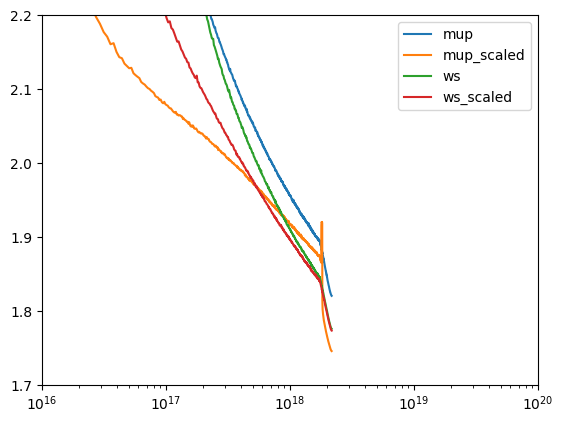

In [29]:
plt.clf()
for k, v in {"mup": mup, "mup_scaled": mup_scaled, "ws": ws, "ws_scaled": ws_scaled}.items():
    plt.plot(v.flops, v[Y_METRIC], label=k)
plt.legend()
plt.xlim(1e16, 1e20)
plt.ylim(1.7, 2.2)
plt.xscale("log")
# plt.yscale("log")

In [34]:
_base_path = "/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/large_batch_cooldown/mup/"
bs128 = read_tb_parquet(_base_path + "s3-s4-b128/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
bs256 = read_tb_parquet(_base_path + "s3-s4-b256/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
bs512 = read_tb_parquet(_base_path + "s3-s4-b512/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
bs768 = read_tb_parquet(_base_path + "s3-s4-b768/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
bs1024 = read_tb_parquet(_base_path + "s3-s4-b1024/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])

(1.5, 4.0)

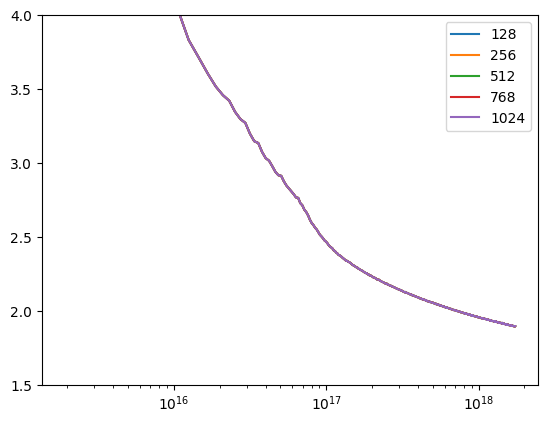

In [36]:
plt.clf()
for k, v in {
    "128": bs128, 
    "256": bs256, 
    "512": bs512, 
    "768": bs768,
    "1024": bs1024
}.items():
    plt.plot(v.flops, v[Y_METRIC], label=k)

plt.legend()
plt.xscale("log")
plt.ylim(1.5, 4)

In [26]:
_base_path = "/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/triangular_lr_schedule/mup/s3-s4/"
bs128 = read_tb_parquet(_base_path + "w=0.1,c=0.9/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
bs256 = read_tb_parquet(_base_path + "w=0.2,c=0.8/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
# bs512 = read_tb_parquet(_base_path + "w=0.3,c=0.7/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
bs768 = read_tb_parquet(_base_path + "w=0.4,c=0.6/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])
bs1024 = read_tb_parquet(_base_path + "w=0.5,c=0.5/seed=666/" + FILENAME).dropna(subset=[Y_METRIC])

(5e+16, 5e+18)

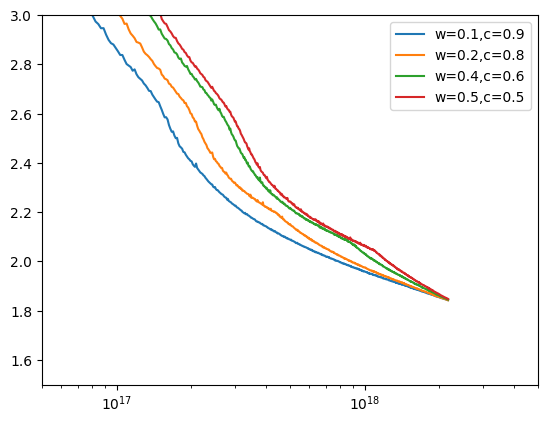

In [30]:
plt.clf()
for k, v in {
    "w=0.1,c=0.9": bs128, 
    "w=0.2,c=0.8": bs256, 
    # "w=0.3,c=0.7": bs512, 
    "w=0.4,c=0.6": bs768,
    "w=0.5,c=0.5": bs1024
}.items():
    plt.plot(v.flops, v[Y_METRIC], label=k)

plt.legend()
plt.xscale("log")
plt.ylim(1.5, 3)
plt.xlim(0.5e17, 0.5e19)

---

## Approach 3: Parametric loss